<a href="https://colab.research.google.com/github/Elnazzareei/RNA-seq-Analysis-of-CMV-Infection-in-Arabidopsis-halleri/blob/main/%20RNA-seq-Analysis-of-CMV-Infection-in-Arabidopsis-halleri_Untitled55.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving GSE197739_genes.count_tracking_1.txt to GSE197739_genes.count_tracking_1.txt
Saving GSE197739_genes.count_tracking_2.txt to GSE197739_genes.count_tracking_2.txt


In [3]:
import pandas as pd

# Enter file paths
file1 = "GSE197739_genes.count_tracking_1.txt"
file2 = "GSE197739_genes.count_tracking_2.txt"

# Load data
df1 = pd.read_csv(file1, sep="\t", index_col=0)
df2 = pd.read_csv(file2, sep="\t", index_col=0)

# Display first 5 rows of each file
print("File 1:")
print(df1.head())
print("\nFile 2:")
print(df2.head())

# Check data dimensions
print("\nFile 1 shape:", df1.shape)
print("File 2 shape:", df2.shape)

# Check for missing values
print("\nMissing values in File 1:\n", df1.isna().sum().sum())
print("Missing values in File 2:\n", df2.isna().sum().sum())

File 1:
                      CMV_count  CMV_count_variance  \
tracking_id                                           
gene:ENSRNA050027841        0.0                 1.0   
gene:ENSRNA050027842        0.0                 0.0   
gene:ENSRNA050027843        0.0                 0.0   
gene:ENSRNA050027844        0.0                 0.0   
gene:ENSRNA050027845        0.0                 0.0   

                      CMV_count_uncertainty_var  CMV_count_dispersion_var  \
tracking_id                                                                 
gene:ENSRNA050027841                          0                       0.0   
gene:ENSRNA050027842                          0                       0.0   
gene:ENSRNA050027843                          0                       0.0   
gene:ENSRNA050027844                          0                       0.0   
gene:ENSRNA050027845                          0                       0.0   

                     CMV_status  Mock_count  Mock_count_variance  

In [4]:
# Select only count columns
counts1 = df1[['CMV_count', 'Mock_count']]
counts2 = df2[['ZnCMV_count', 'ZnMock_count']]

# Rename columns for better clarity
counts1.columns = ['CMV', 'Mock']
counts2.columns = ['ZnCMV', 'ZnMock']

# Merge based on index (Gene ID)
merged_counts = pd.concat([counts1, counts2], axis=1)

# Display first 5 rows of the merged dataframe
print(merged_counts.head())

# Check final dimensions
print("Merged counts shape:", merged_counts.shape)

                      CMV  Mock  ZnCMV  ZnMock
tracking_id                                   
gene:ENSRNA050027841  0.0   0.0    0.0     0.0
gene:ENSRNA050027842  0.0   0.0    0.0     0.0
gene:ENSRNA050027843  0.0   0.0    0.0     0.0
gene:ENSRNA050027844  0.0   0.0    0.0     0.0
gene:ENSRNA050027845  0.0   0.0    0.0     0.0
Merged counts shape: (33223, 4)


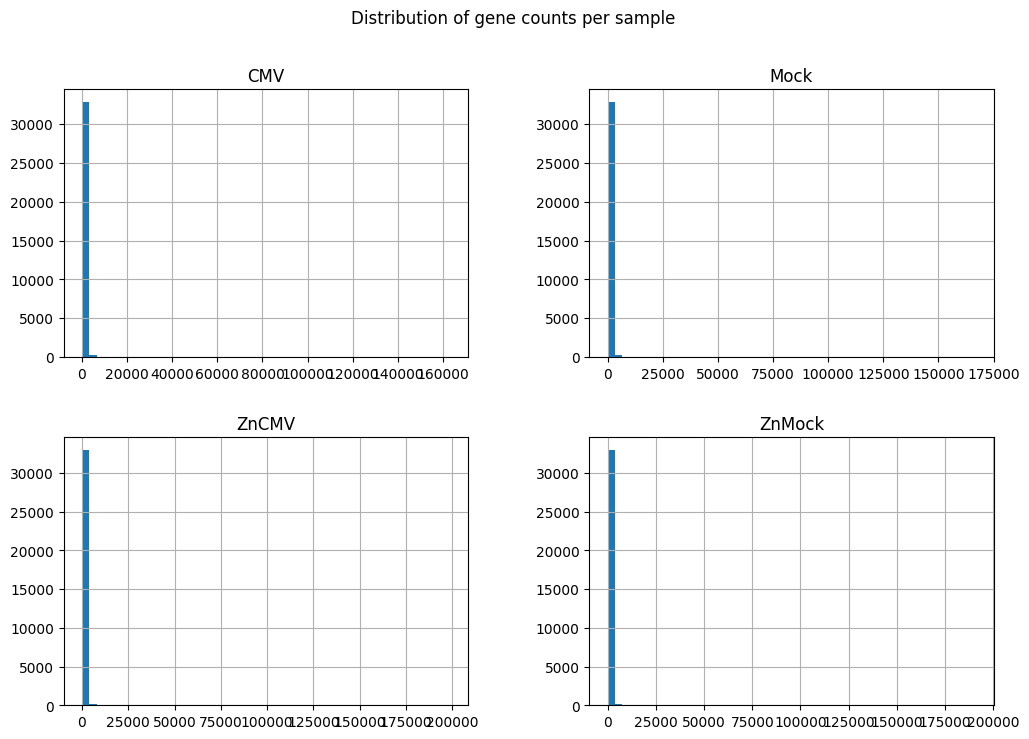

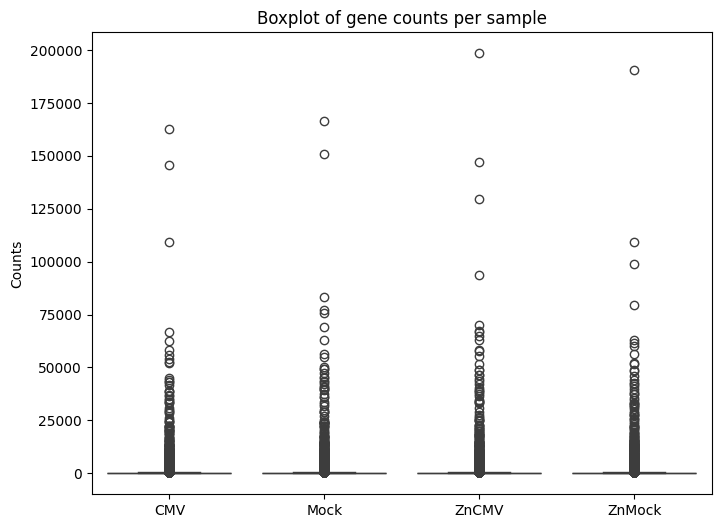

Shape after removing genes with all zeros: (25682, 4)


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram for each sample
merged_counts.hist(bins=50, figsize=(12,8))
plt.suptitle("Distribution of gene counts per sample")
plt.show()

# Boxplot to visualize sample variability
plt.figure(figsize=(8,6))
sns.boxplot(data=merged_counts)
plt.title("Boxplot of gene counts per sample")
plt.ylabel("Counts")
plt.show()

# Remove genes with all zero counts
filtered_counts = merged_counts[(merged_counts > 0).any(axis=1)]
print("Shape after removing genes with all zeros:", filtered_counts.shape)

                           CMV      Mock     ZnCMV    ZnMock
tracking_id                                                 
gene:ENSRNA050029286  0.031443  0.000000  0.033585  0.111434
gene:ENSRNA050029292  0.000000  0.056303  0.026292  0.000000
gene:ENSRNA050029297  0.000000  0.000000  0.000000  0.033041
gene:ENSRNA050029300  0.000000  0.027370  0.027430  0.000000
gene:ENSRNA050029302  0.000000  0.000000  0.000000  0.028157


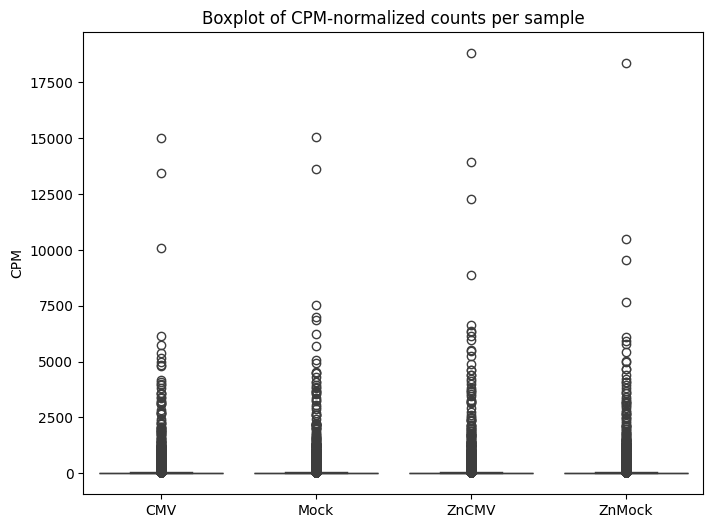

In [6]:
# Calculate total counts for each sample
sample_sums = filtered_counts.sum(axis=0)

# Compute CPM (Counts Per Million)
cpm = filtered_counts.divide(sample_sums, axis=1) * 1e6

# Display first 5 rows
print(cpm.head())

# Plot boxplot after normalization
plt.figure(figsize=(8,6))
sns.boxplot(data=cpm)
plt.title("Boxplot of CPM-normalized counts per sample")
plt.ylabel("CPM")
plt.show()

In [7]:
import numpy as np
from scipy.stats import ttest_ind

# Define groups
group1 = cpm[['CMV', 'ZnCMV']]    # treatment
group2 = cpm[['Mock', 'ZnMock']]  # control

# Calculate mean expression and log2 fold change
mean_group1 = group1.mean(axis=1)
mean_group2 = group2.mean(axis=1)
log2fc = np.log2((mean_group1 + 1e-6) / (mean_group2 + 1e-6))  # add small value to avoid division by zero

# Calculate p-values using t-test (assuming independent samples)
p_values = []
for gene in cpm.index:
    t_stat, p = ttest_ind(group1.loc[gene], group2.loc[gene])
    p_values.append(p)

# Create results dataframe
de_results = pd.DataFrame({
    'log2FC': log2fc,
    'p_value': p_values
}, index=cpm.index)

# Sort by p-value
de_results = de_results.sort_values('p_value')

# Display top 5 most differentially expressed genes
print(de_results.head())


                log2FC   p_value
tracking_id                     
gene:g16250   2.137069  0.000018
gene:g21697  15.042992  0.000025
gene:g29557   0.411899  0.000025
gene:g31006  15.042783  0.000025
gene:g28611  15.042783  0.000025


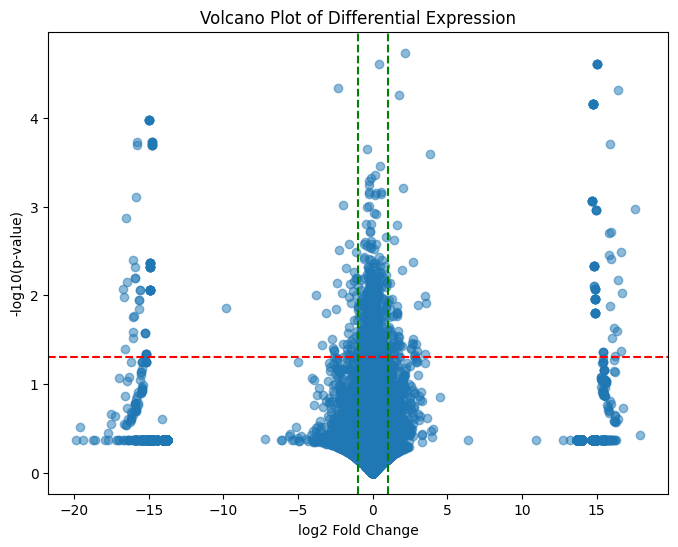

In [8]:
import matplotlib.pyplot as plt

# Calculate -log10(p-value)
de_results['neg_log10_p'] = -np.log10(de_results['p_value'])

plt.figure(figsize=(8,6))
plt.scatter(de_results['log2FC'], de_results['neg_log10_p'], alpha=0.5)
plt.xlabel('log2 Fold Change')
plt.ylabel('-log10(p-value)')
plt.title('Volcano Plot of Differential Expression')
plt.axhline(y=-np.log10(0.05), color='red', linestyle='--')  # p=0.05 significance threshold
plt.axvline(x=1, color='green', linestyle='--')  # significant fold change
plt.axvline(x=-1, color='green', linestyle='--')
plt.show()

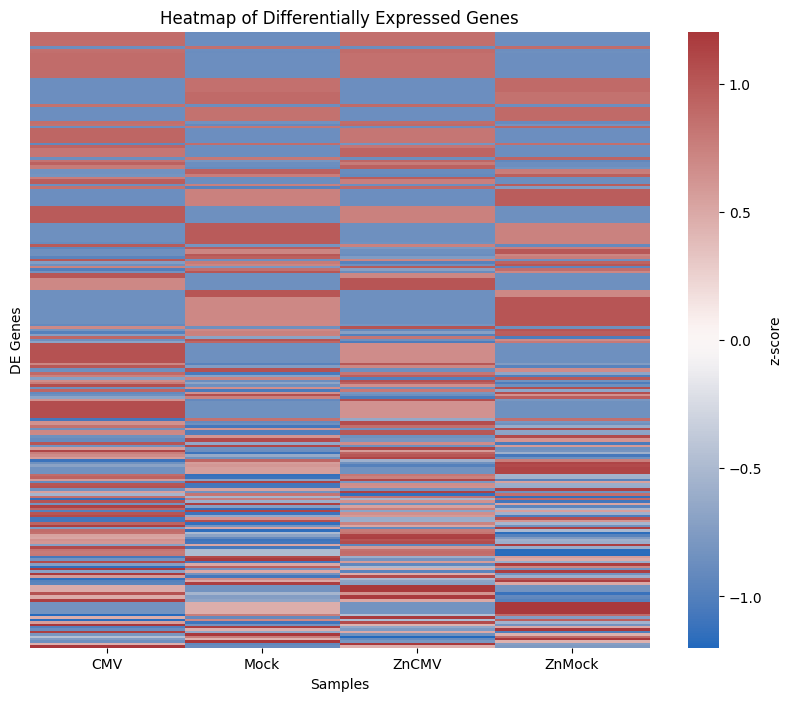

In [9]:
import seaborn as sns

# Filter differentially expressed genes
sig_genes = de_results[(abs(de_results['log2FC']) > 1) & (de_results['p_value'] < 0.05)].index

# Prepare dataframe for heatmap
heatmap_data = cpm.loc[sig_genes]

# Standardize each gene (z-score)
heatmap_data_z = (heatmap_data - heatmap_data.mean(axis=1).values.reshape(-1,1)) / heatmap_data.std(axis=1).values.reshape(-1,1)

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(heatmap_data_z, cmap='vlag', cbar_kws={'label': 'z-score'}, yticklabels=False)
plt.title('Heatmap of Differentially Expressed Genes')
plt.xlabel('Samples')
plt.ylabel('DE Genes')
plt.show()